# Spotify Streaming Audit - EDA Completo
**Equipo 3** | TripleTen Data Science Bootcamp

---

## Indice
1. Configuracion del entorno
2. Carga y primera inspeccion de datos
3. Verificacion de calidad de datos
4. Analisis estadistico descriptivo
5. Distribuciones de variables
6. Popularidad vs Loudness y Danceability
7. Cadena de correlaciones: Loudness -> Energy -> Acousticness
8. Segmentos de alto y bajo rendimiento
9. Analisis por genero y por decada
10. Cruce con Grammy Awards
11. Hallazgos clave y recomendaciones

---
## 1. Configuracion del entorno

In [1]:
!pip install -q seaborn --upgrade


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y primera inspeccion de datos

In [3]:
# OPCION A: Subir manualmente
# from google.colab import files
# uploaded = files.upload()

# OPCION B: Desde Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA = '/content/drive/MyDrive/TU_CARPETA/spotify-2000-joined-clean.csv'

# OPCION C (por defecto)
RUTA = 'spotify-2000-joined-clean.csv'

df = pd.read_csv(RUTA)
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 1,994 filas x 17 columnas


In [4]:
df.head()

,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,media-alta,True
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,alta,True
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,alta,True
3,uninvited,alanis_morissette,alternative_rock,2005,127,54,38,-5,9,19,276,2,3,57,2000,media-baja,True
4,cry_me_a_river,justin_timberlake,dance_pop,2002,74,65,62,-7,10,56,288,57,18,74,2000,alta,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   title               1994 non-null   str  
 1   artist              1994 non-null   str  
 2   genre               1994 non-null   str  
 3   year                1994 non-null   int64
 4   bpm                 1994 non-null   int64
 5   energy              1994 non-null   int64
 6   danceability        1994 non-null   int64
 7   loudness_db         1994 non-null   int64
 8   liveness            1994 non-null   int64
 9   valence             1994 non-null   int64
 10  duration            1994 non-null   int64
 11  acousticness        1994 non-null   int64
 12  speechiness         1994 non-null   int64
 13  popularity          1994 non-null   int64
 14  decade              1994 non-null   int64
 15  popularity_segment  1994 non-null   str  
 16  winner              1994 non-null   bool 
dtypes: boo

In [6]:
columnas_descripcion = {
    'title'              : 'Nombre de la cancion',
    'artist'             : 'Artista (normalizado a minusculas)',
    'genre'              : 'Genero musical principal',
    'year'               : 'Anio de lanzamiento',
    'bpm'                : 'Beats Por Minuto - tempo de la cancion',
    'energy'             : 'Intensidad y actividad percibida (0-100)',
    'danceability'       : 'Que tan bailable es la cancion (0-100)',
    'loudness_db'        : 'Volumen promedio en decibeles (valores negativos)',
    'liveness'           : 'Probabilidad de grabacion en vivo (0-100)',
    'valence'            : 'Positividad musical: alto = alegre, bajo = triste (0-100)',
    'duration'           : 'Duracion en segundos',
    'acousticness'       : 'Nivel de elementos acusticos (0-100)',
    'speechiness'        : 'Presencia de palabras habladas (0-100)',
    'popularity'         : 'Score de popularidad en Spotify (0-100) - variable objetivo',
    'decade'             : 'Decada del lanzamiento',
    'popularity_segment' : 'Cuartil de popularidad: baja / media-baja / media-alta / alta',
    'winner'             : 'True si el artista gano al menos un Grammy Award',
}
for col, desc in columnas_descripcion.items():
    print(f'  {col:<22} -> {desc}')

  title                  -> Nombre de la cancion
  artist                 -> Artista (normalizado a minusculas)
  genre                  -> Genero musical principal
  year                   -> Anio de lanzamiento
  bpm                    -> Beats Por Minuto - tempo de la cancion
  energy                 -> Intensidad y actividad percibida (0-100)
  danceability           -> Que tan bailable es la cancion (0-100)
  loudness_db            -> Volumen promedio en decibeles (valores negativos)
  liveness               -> Probabilidad de grabacion en vivo (0-100)
  valence                -> Positividad musical: alto = alegre, bajo = triste (0-100)
  duration               -> Duracion en segundos
  acousticness           -> Nivel de elementos acusticos (0-100)
  speechiness            -> Presencia de palabras habladas (0-100)
  popularity             -> Score de popularidad en Spotify (0-100) - variable objetivo
  decade                 -> Decada del lanzamiento
  popularity_segment     -> Cu

---
## 3. Verificacion de calidad de datos

In [7]:
# 3.1 Valores nulos
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('Sin valores nulos.')
else:
    print('Columnas con nulos:')
    print(nulos[nulos > 0])

Sin valores nulos.


In [8]:
# 3.2 Duplicados
duplicados = df.duplicated(subset=['title', 'artist']).sum()
if duplicados == 0:
    print('Sin registros duplicados.')
else:
    print(f'{duplicados} duplicados. Eliminando...')
    df = df.drop_duplicates(subset=['title', 'artist']).reset_index(drop=True)
    print(f'Dataset limpio: {len(df):,} filas')

Sin registros duplicados.


In [9]:
# 3.3 Correccion de tipos numericos
ATRIBUTOS_NUMERICOS = [
    'bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'duration', 'acousticness', 'speechiness'
]
for col in ATRIBUTOS_NUMERICOS:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )
print('Tipos corregidos.')
print(df[ATRIBUTOS_NUMERICOS].dtypes)

Tipos corregidos.
bpm             int64
energy          int64
danceability    int64
loudness_db     int64
liveness        int64
valence         int64
duration        int64
acousticness    int64
speechiness     int64
dtype: object


In [10]:
# 3.4 Variables auxiliares
df['decade_label'] = df['decade'].astype(str) + 's'
ORDEN_SEGMENTOS = ['baja', 'media-baja', 'media-alta', 'alta']

print('Decadas:', sorted(df['decade_label'].unique()))
print()
print('Canciones por segmento:')
print(df['popularity_segment'].value_counts().reindex(ORDEN_SEGMENTOS))

Decadas: ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']

Canciones por segmento:
popularity_segment
baja          499
media-baja    540
media-alta    497
alta          458
Name: count, dtype: int64


In [11]:
# 3.5 Snapshot final
print(f'Dataset listo  |  {len(df):,} filas')
print(f'Rango de anios: {df["year"].min()} - {df["year"].max()}')
print(f'Generos unicos: {df["genre"].nunique()}')
print(f'Artistas unicos: {df["artist"].nunique()}')
df.head(3)

Dataset listo  |  1,994 filas
Rango de anios: 1956 - 2019
Generos unicos: 149
Artistas unicos: 731


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner,decade_label
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,media-alta,True,2000s
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,alta,True,2000s
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,alta,True,2000s


---
## 4. Analisis estadistico descriptivo

In [12]:
ATRIBUTOS = [
    'bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'duration', 'acousticness',
    'speechiness', 'popularity'
]

# count=no nulos | mean=promedio | std=dispersion | 25/50/75%=cuartiles
df[ATRIBUTOS].describe().round(2)

,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity
count,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00
mean,120.22,59.68,53.24,-9.01,19.01,49.41,262.44,28.86,4.99,59.53
std,28.03,22.15,15.35,3.65,16.73,24.86,93.60,29.01,4.40,14.35
min,37.00,3.00,10.00,-27.00,2.00,3.00,93.00,0.00,2.00,11.00
25%,99.00,42.00,43.00,-11.00,9.00,29.00,212.00,3.00,3.00,49.25
50%,119.00,61.00,53.00,-8.00,12.00,47.00,245.00,18.00,4.00,62.00
75%,136.00,78.00,64.00,-6.00,23.00,69.75,289.00,50.00,5.00,71.00
max,206.00,100.00,96.00,-2.00,99.00,99.00,1412.00,99.00,55.00,100.00


In [13]:
# Popularidad promedio por segmento
print('Estadisticas de popularity por segmento:')
(df.groupby('popularity_segment', observed=True)['popularity']
   .describe()
   .reindex(ORDEN_SEGMENTOS)
   .round(2))

Estadisticas de popularity por segmento:


,count,mean,std,min,25%,50%,75%,max
popularity_segment,,,,,,,,
baja,499.0,39.82,8.10,11.0,36.0,42.0,46.0,49.0
media-baja,540.0,56.41,3.64,50.0,53.0,57.0,59.0,62.0
media-alta,497.0,66.97,2.52,63.0,65.0,67.0,69.0,71.0
alta,458.0,76.59,4.10,72.0,74.0,76.0,79.0,100.0


---
## 5. Distribuciones de variables

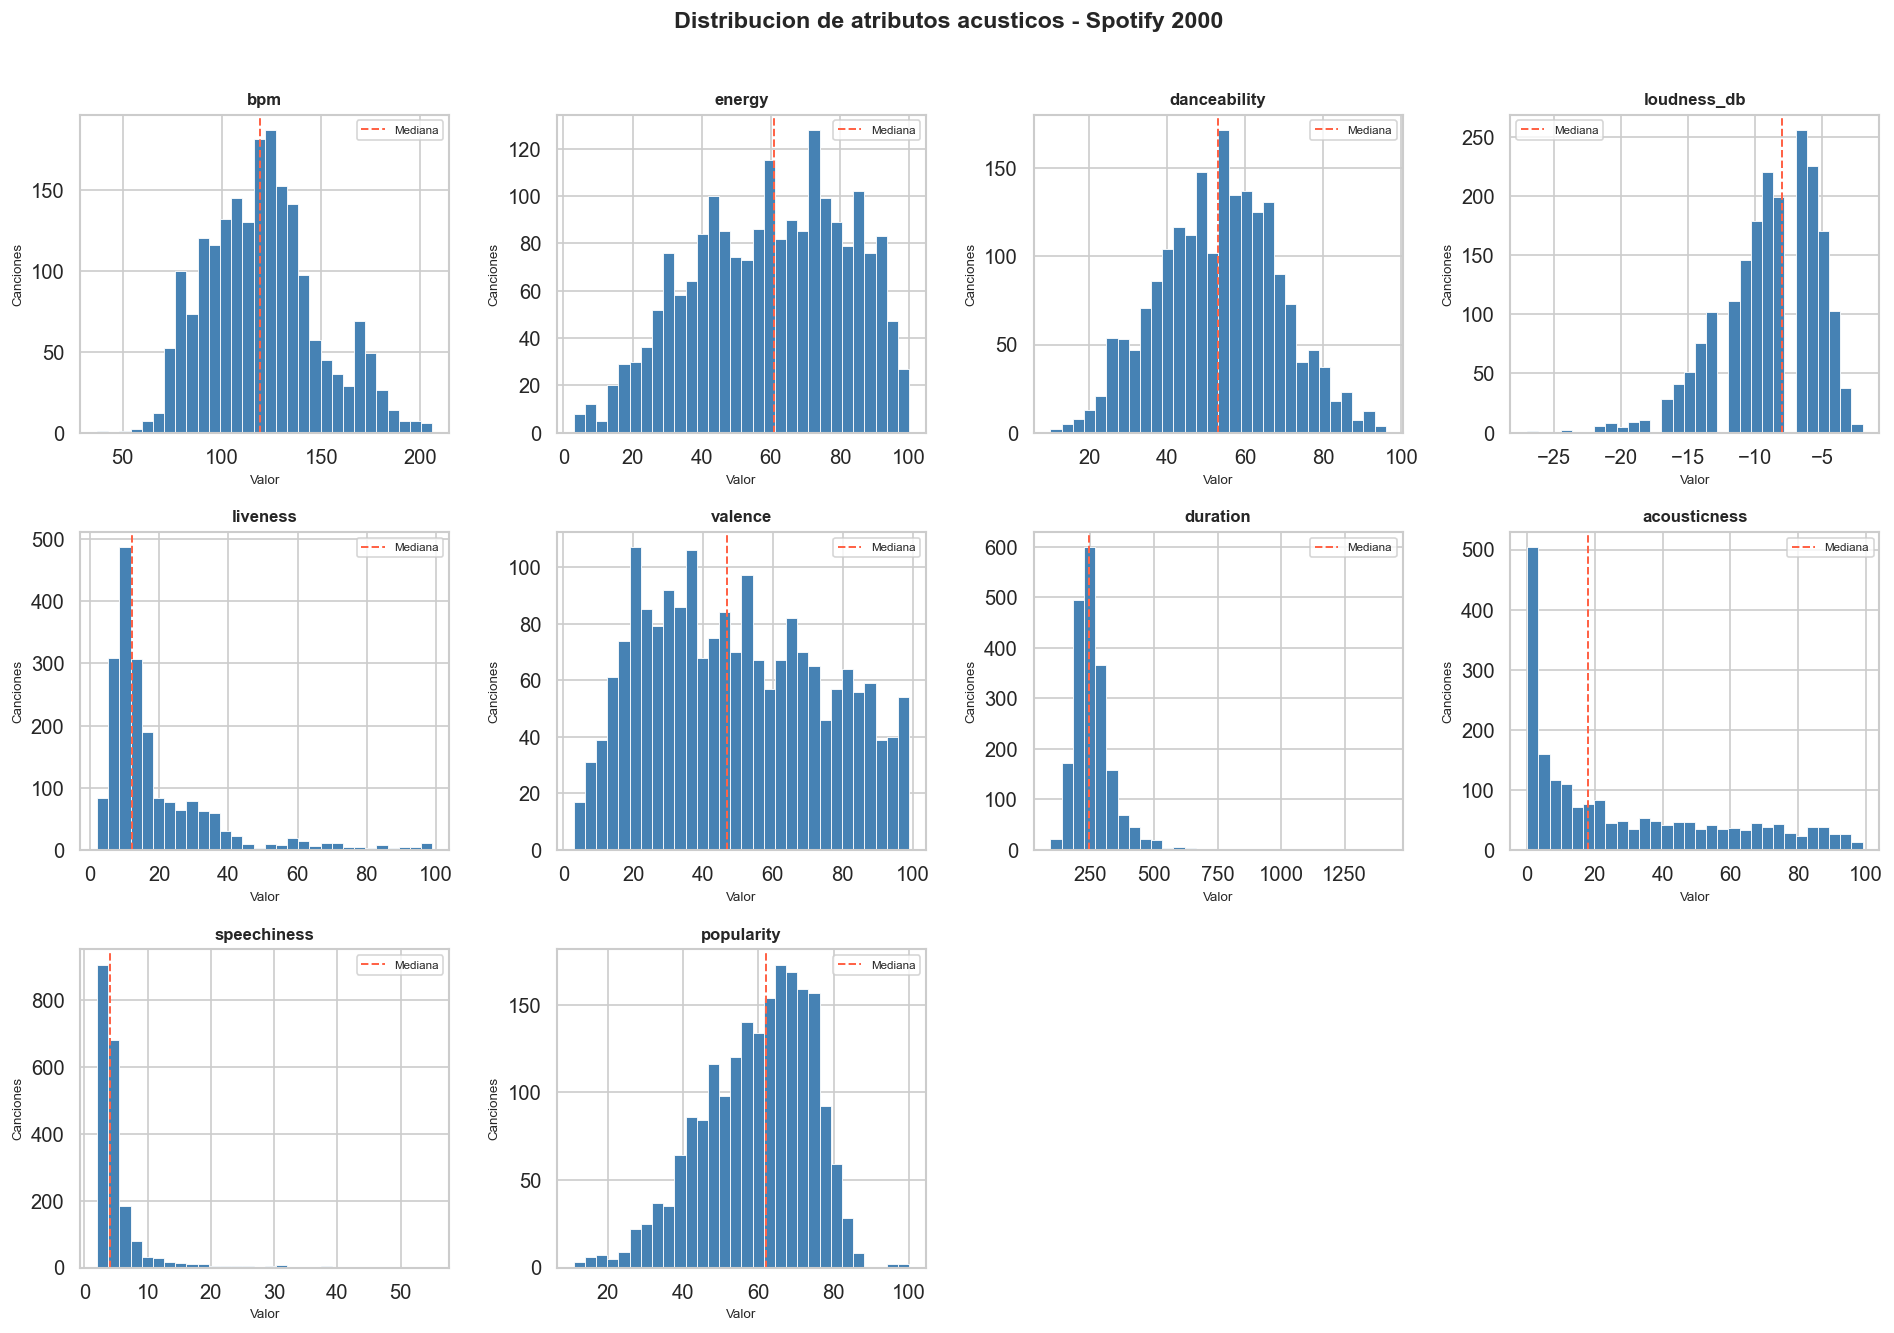

In [14]:
# 5.1 Histogramas de todos los atributos
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(ATRIBUTOS):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Canciones', fontsize=8)
    axes[i].axvline(df[col].median(), color='tomato',
                    linestyle='--', linewidth=1.2, label='Mediana')
    axes[i].legend(fontsize=7)

for j in range(len(ATRIBUTOS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de atributos acusticos - Spotify 2000',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

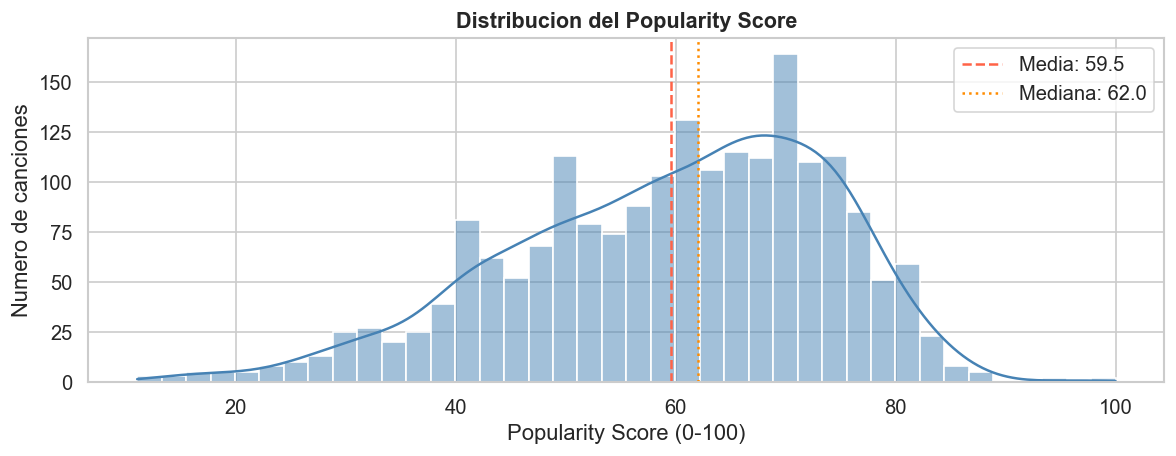

Media:   59.5
Mediana: 62.0
Std:     14.4


In [15]:
# 5.2 Distribucion de popularity - variable objetivo
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['popularity'], bins=40, kde=True, ax=ax, color='steelblue')
ax.axvline(df['popularity'].mean(),   color='tomato',    linestyle='--',
           label=f'Media: {df["popularity"].mean():.1f}')
ax.axvline(df['popularity'].median(), color='darkorange', linestyle=':',
           label=f'Mediana: {df["popularity"].median():.1f}')
ax.set_title('Distribucion del Popularity Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity Score (0-100)')
ax.set_ylabel('Numero de canciones')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Media:   {df["popularity"].mean():.1f}')
print(f'Mediana: {df["popularity"].median():.1f}')
print(f'Std:     {df["popularity"].std():.1f}')

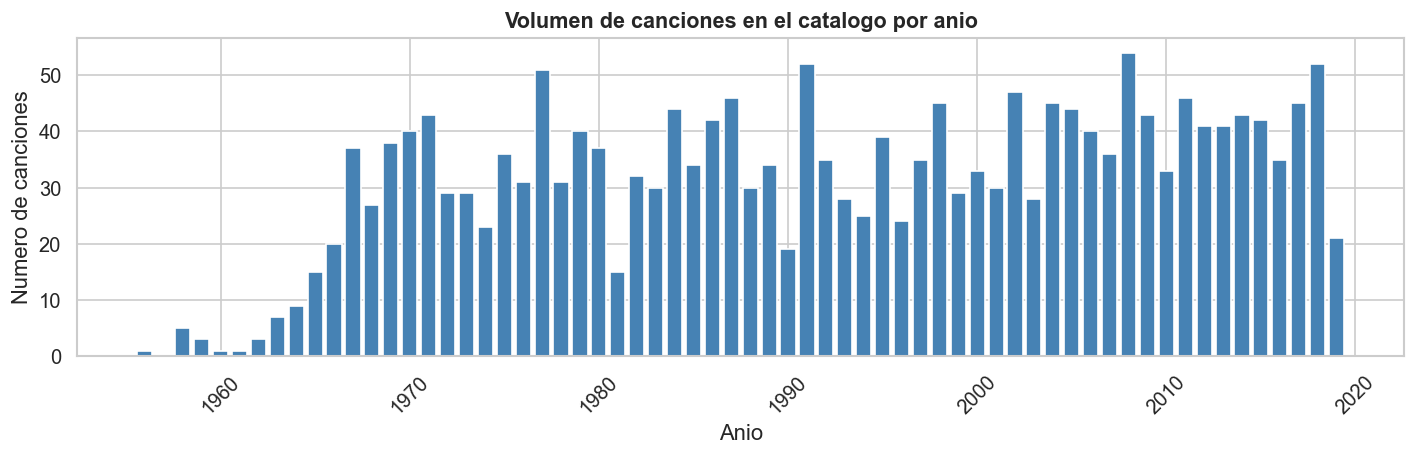

In [16]:
# 5.3 Volumen de canciones por anio
canciones_por_anio = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(canciones_por_anio.index, canciones_por_anio.values,
       color='steelblue', edgecolor='white')
ax.set_title('Volumen de canciones en el catalogo por anio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Anio')
ax.set_ylabel('Numero de canciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Popularidad vs Loudness y Danceability

Primer paso de la cadena: identificar que atributos se relacionan directamente
con la popularidad. Nos enfocamos en **loudness_db** y **danceability**
como los dos factores con mayor impacto.

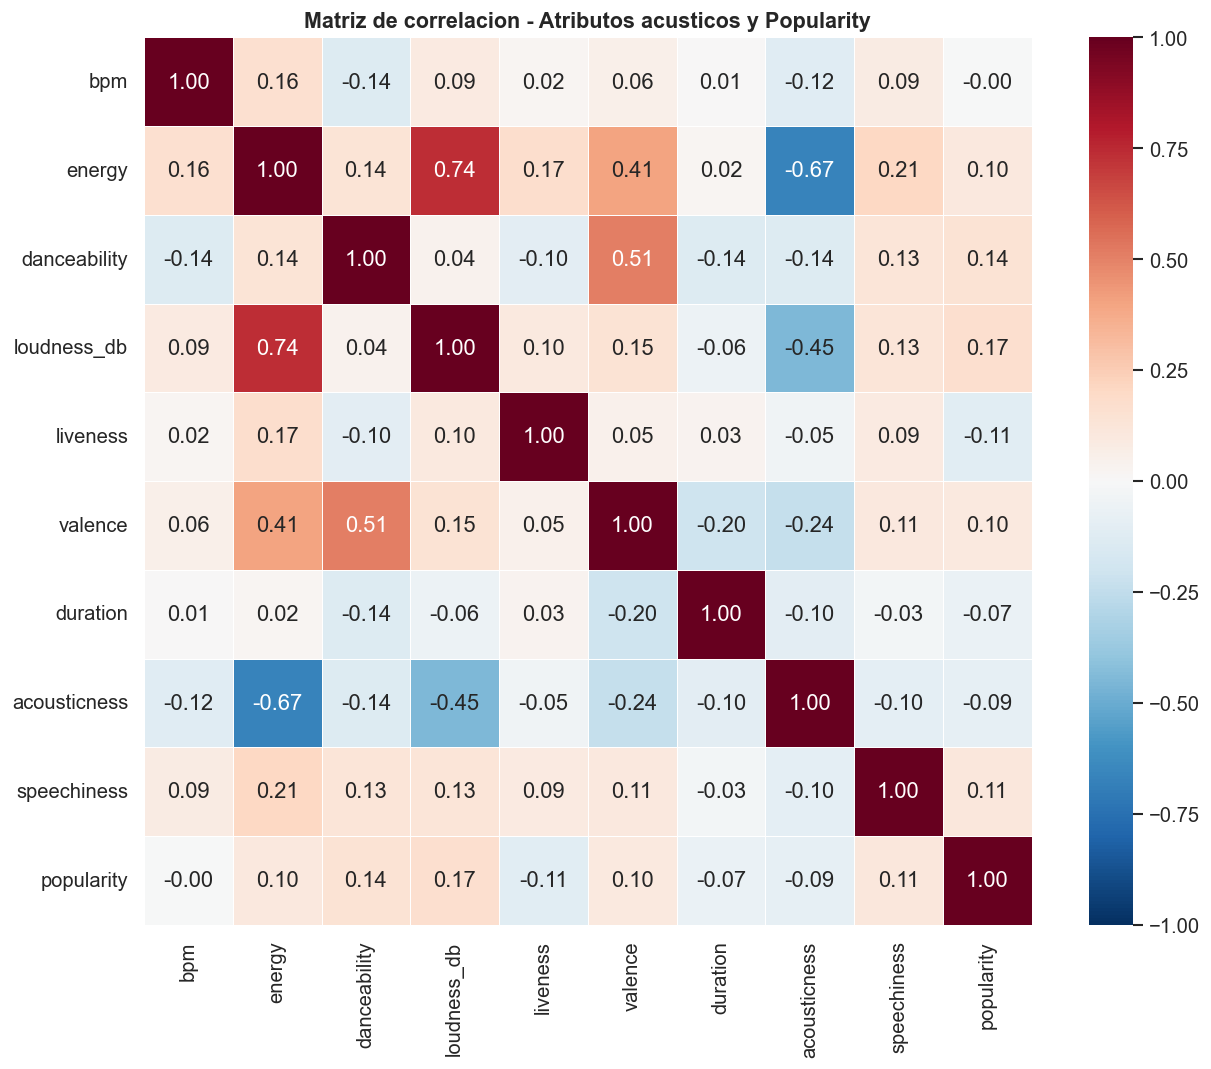

In [17]:
# 6.1 Matriz de correlacion completa
matriz_corr = df[ATRIBUTOS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matriz_corr,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, ax=ax
)
ax.set_title('Matriz de correlacion - Atributos acusticos y Popularity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

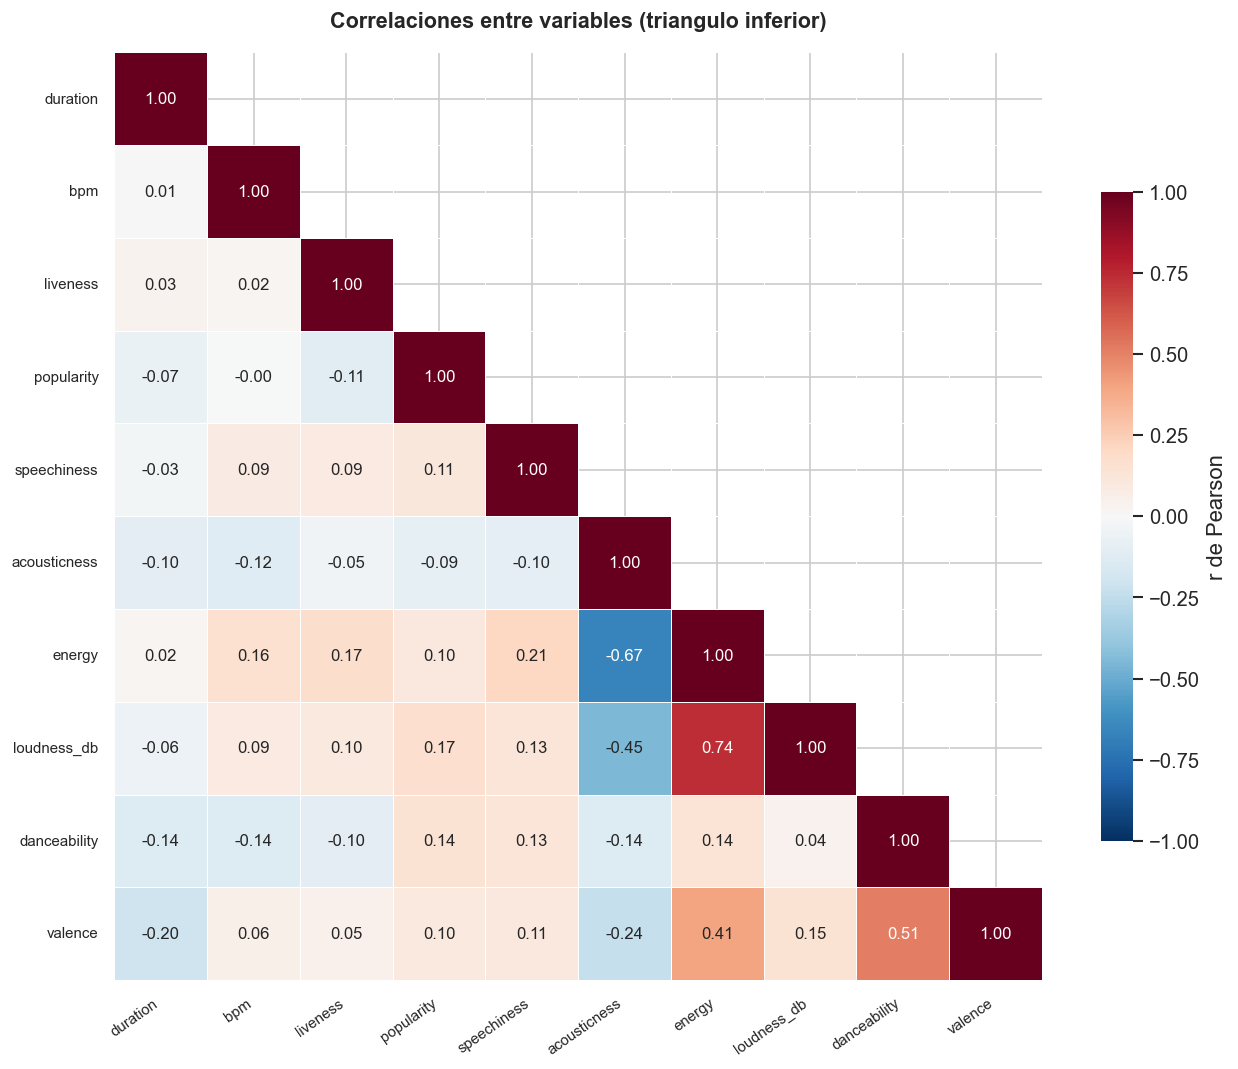

In [18]:
# 6.2 Mapa de calor - triangulo inferior (version limpia)
# .values.copy() evita el error de array de solo lectura
distancias = (1 - matriz_corr.abs()).values.copy()
np.fill_diagonal(distancias, 0)
linkage = hierarchy.linkage(squareform(distancias), method='average')
orden   = hierarchy.leaves_list(linkage)
atributos_ordenados = [ATRIBUTOS[i] for i in orden]
matriz_ordenada     = matriz_corr.loc[atributos_ordenados, atributos_ordenados]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(matriz_ordenada, dtype=bool), k=1)
sns.heatmap(
    matriz_ordenada, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}, ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'r de Pearson'}
)
ax.set_title('Correlaciones entre variables (triangulo inferior)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

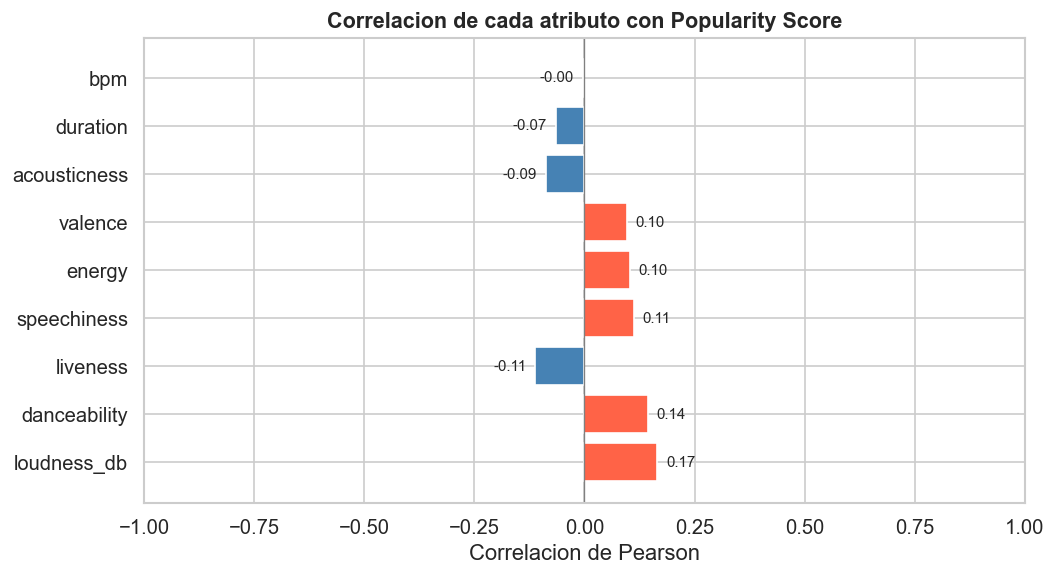

Correlaciones con popularity:
loudness_db     0.166
danceability    0.144
liveness       -0.112
speechiness     0.112
energy          0.103
valence         0.096
acousticness   -0.088
duration       -0.065
bpm            -0.003


In [19]:
# 6.3 Ranking completo de correlaciones con popularity
corr_con_popularity = (
    matriz_corr['popularity']
    .drop('popularity')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['tomato' if v > 0 else 'steelblue' for v in corr_con_popularity.values]
ax.barh(corr_con_popularity.index, corr_con_popularity.values,
        color=colores, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlacion de cada atributo con Popularity Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlacion de Pearson')
ax.set_xlim(-1, 1)

for i, (val, _) in enumerate(zip(corr_con_popularity.values, corr_con_popularity.index)):
    ax.text(val + (0.02 if val >= 0 else -0.02), i, f'{val:.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('Correlaciones con popularity:')
print(corr_con_popularity.round(3).to_string())

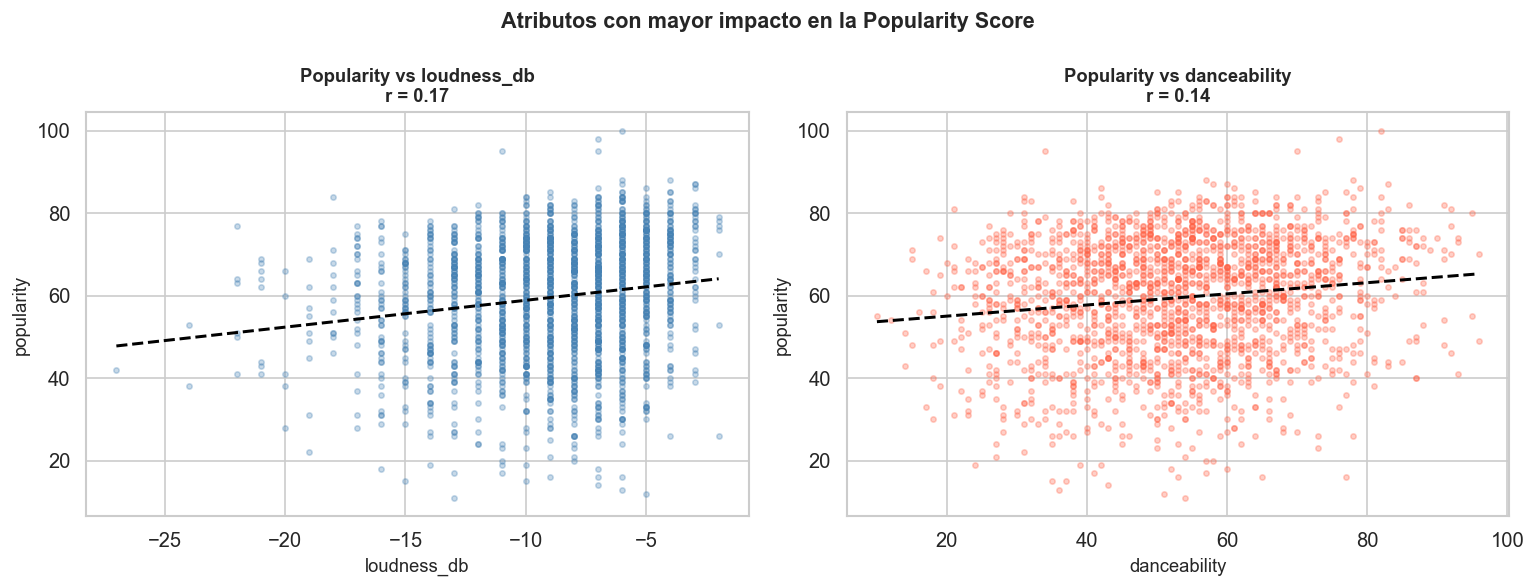

loudness_db  -> r = 0.166  | canciones mas fuertes = mas populares
danceability -> r = 0.144  | canciones mas bailables = mas populares


In [20]:
# 6.4 Enfoque: Popularity vs Loudness_db y Danceability
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color in zip(axes,
                           ['loudness_db', 'danceability'],
                           ['steelblue',   'tomato']):
    ax.scatter(df[col], df['popularity'], alpha=0.3, s=10, color=color)
    m, b = np.polyfit(df[col].dropna(),
                      df.loc[df[col].notna(), 'popularity'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')
    r = corr_con_popularity[col]
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('popularity', fontsize=11)
    ax.set_title(f'Popularity vs {col}\nr = {r:.2f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Atributos con mayor impacto en la Popularity Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

r_loud  = corr_con_popularity['loudness_db']
r_dance = corr_con_popularity['danceability']
print(f'loudness_db  -> r = {r_loud:.3f}  | canciones mas fuertes = mas populares')
print(f'danceability -> r = {r_dance:.3f}  | canciones mas bailables = mas populares')

---
## 7. Cadena de correlaciones: Loudness -> Energy -> Acousticness

Si el volumen impacta la popularidad, que hay detras del volumen?
Analizamos: **loudness_db <-> energy** y **energy <-> acousticness**.

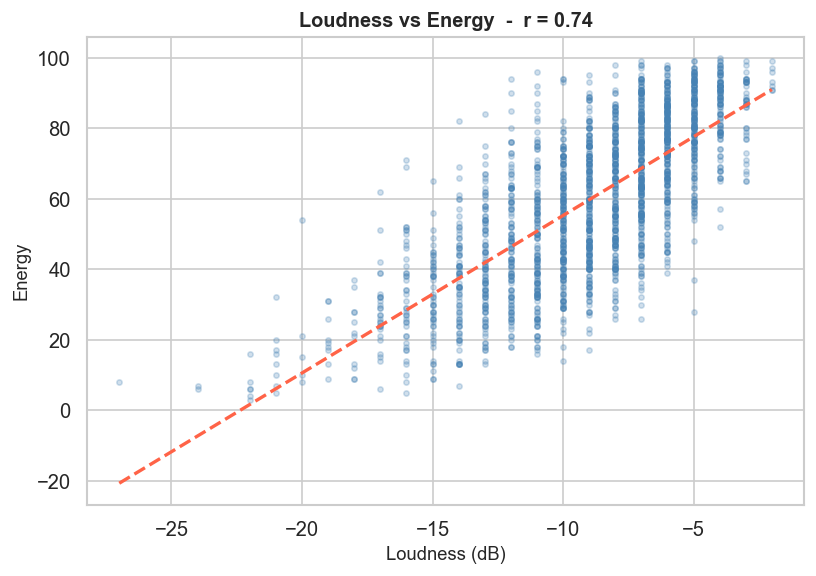

Correlacion loudness_db <-> energy: r = 0.736
Interpretacion: canciones mas fuertes son casi siempre mas energeticas.


In [21]:
# 7.1 Loudness_db <-> Energy
r_le = matriz_corr.loc['loudness_db', 'energy']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['loudness_db'], df['energy'], alpha=0.25, s=10, color='steelblue')
m, b = np.polyfit(df['loudness_db'], df['energy'], 1)
x_line = np.linspace(df['loudness_db'].min(), df['loudness_db'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, linestyle='--')
ax.set_xlabel('Loudness (dB)', fontsize=11)
ax.set_ylabel('Energy', fontsize=11)
ax.set_title(f'Loudness vs Energy  -  r = {r_le:.2f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Correlacion loudness_db <-> energy: r = {r_le:.3f}')
print('Interpretacion: canciones mas fuertes son casi siempre mas energeticas.')

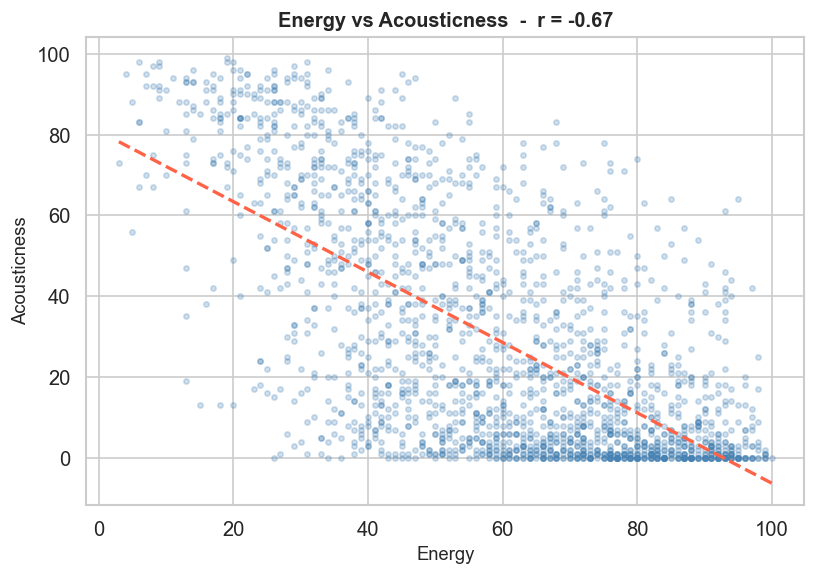

Correlacion energy <-> acousticness: r = -0.665
Interpretacion: canciones acusticas son menos energeticas - dos perfiles opuestos.


In [22]:
# 7.2 Energy <-> Acousticness
r_ea = matriz_corr.loc['energy', 'acousticness']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['energy'], df['acousticness'], alpha=0.25, s=10, color='steelblue')
m, b = np.polyfit(df['energy'], df['acousticness'], 1)
x_line = np.linspace(df['energy'].min(), df['energy'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, linestyle='--')
ax.set_xlabel('Energy', fontsize=11)
ax.set_ylabel('Acousticness', fontsize=11)
ax.set_title(f'Energy vs Acousticness  -  r = {r_ea:.2f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Correlacion energy <-> acousticness: r = {r_ea:.3f}')
print('Interpretacion: canciones acusticas son menos energeticas - dos perfiles opuestos.')

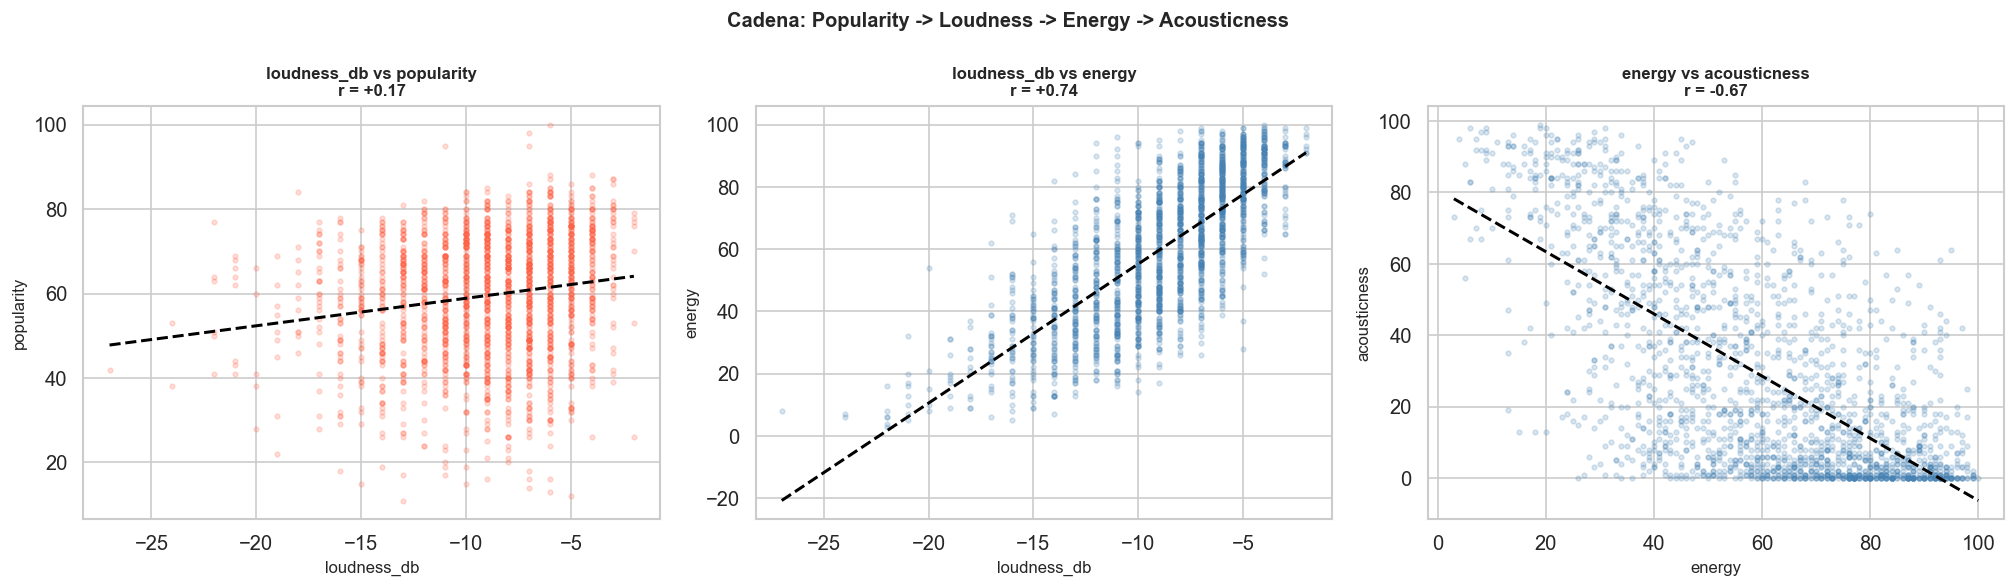

In [23]:
# 7.3 Resumen visual: cadena completa en 3 graficas
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pares = [
    ('loudness_db', 'popularity',  corr_con_popularity['loudness_db'],          'tomato'),
    ('loudness_db', 'energy',       matriz_corr.loc['loudness_db', 'energy'],   'steelblue'),
    ('energy',      'acousticness', matriz_corr.loc['energy', 'acousticness'],  'steelblue'),
]

for ax, (x_col, y_col, r, color) in zip(axes, pares):
    ax.scatter(df[x_col], df[y_col], alpha=0.2, s=8, color=color)
    m, b = np.polyfit(df[x_col], df[y_col], 1)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    signo = '+' if r > 0 else ''
    ax.set_title(f'{x_col} vs {y_col}\nr = {signo}{r:.2f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Cadena: Popularity -> Loudness -> Energy -> Acousticness',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Segmentos de alto y bajo rendimiento

In [24]:
# 8.1 Perfil acustico promedio por segmento
ATRIBUTOS_PERFIL = [
    'bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'duration', 'acousticness', 'speechiness'
]
perfil_segmento = (
    df.groupby('popularity_segment', observed=True)[ATRIBUTOS_PERFIL]
    .mean()
    .reindex(ORDEN_SEGMENTOS)
    .round(1)
)
print('Perfil acustico promedio por segmento:')
perfil_segmento

Perfil acustico promedio por segmento:


,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness
popularity_segment,,,,,,,,,
baja,120.6,57.0,51.3,-9.6,21.8,47.1,271.2,32.4,4.7
media-baja,119.9,58.9,51.8,-9.3,18.7,47.0,264.6,28.8,4.5
media-alta,122.1,59.9,53.6,-9.1,18.4,51.7,261.8,29.6,4.9
alta,118.2,63.3,56.7,-7.8,17.0,52.2,251.1,24.3,5.9


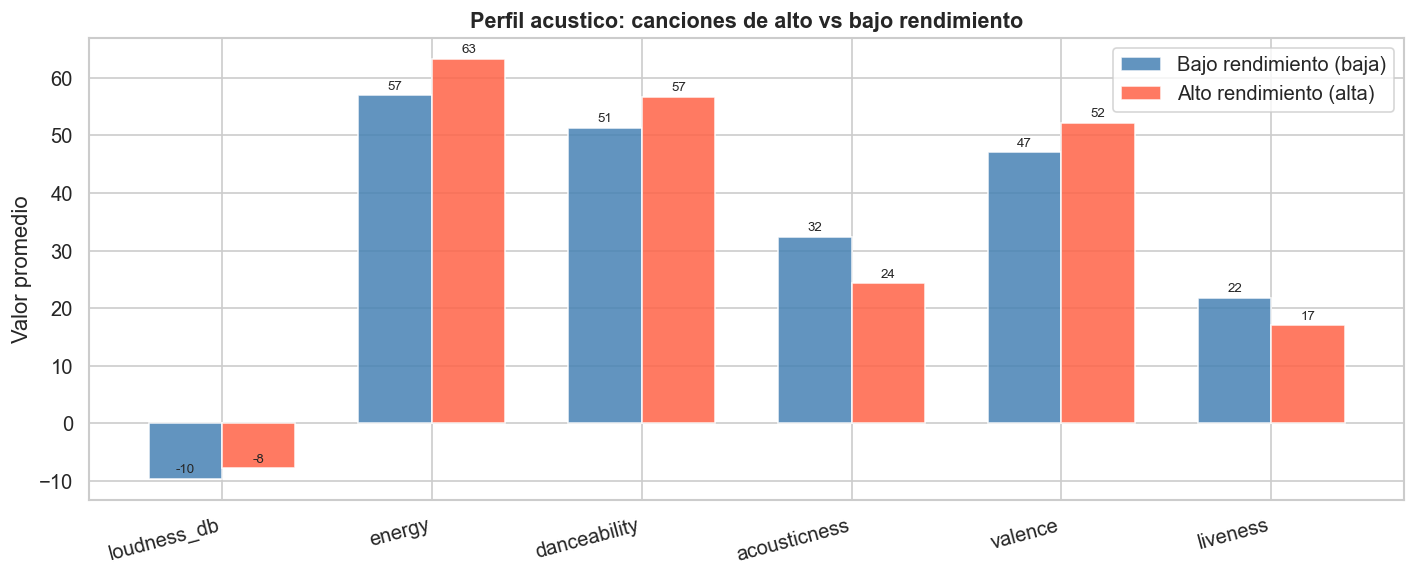

In [25]:
# 8.2 Comparacion visual: alta vs baja
# Enfocado en los atributos de la cadena de analisis
atributos_plot = ['loudness_db', 'energy', 'danceability', 'acousticness', 'valence', 'liveness']

q_baja = perfil_segmento.loc['baja', atributos_plot]
q_alta = perfil_segmento.loc['alta', atributos_plot]
x = np.arange(len(atributos_plot))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
barras_baja = ax.bar(x - ancho/2, q_baja, ancho,
                     label='Bajo rendimiento (baja)', color='steelblue', alpha=0.85)
barras_alta = ax.bar(x + ancho/2, q_alta, ancho,
                     label='Alto rendimiento (alta)',  color='tomato',    alpha=0.85)

ax.set_title('Perfil acustico: canciones de alto vs bajo rendimiento',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(atributos_plot, rotation=15, ha='right')
ax.set_ylabel('Valor promedio')
ax.legend()

for barra in [*barras_baja, *barras_alta]:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2., altura + 0.5,
            f'{altura:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

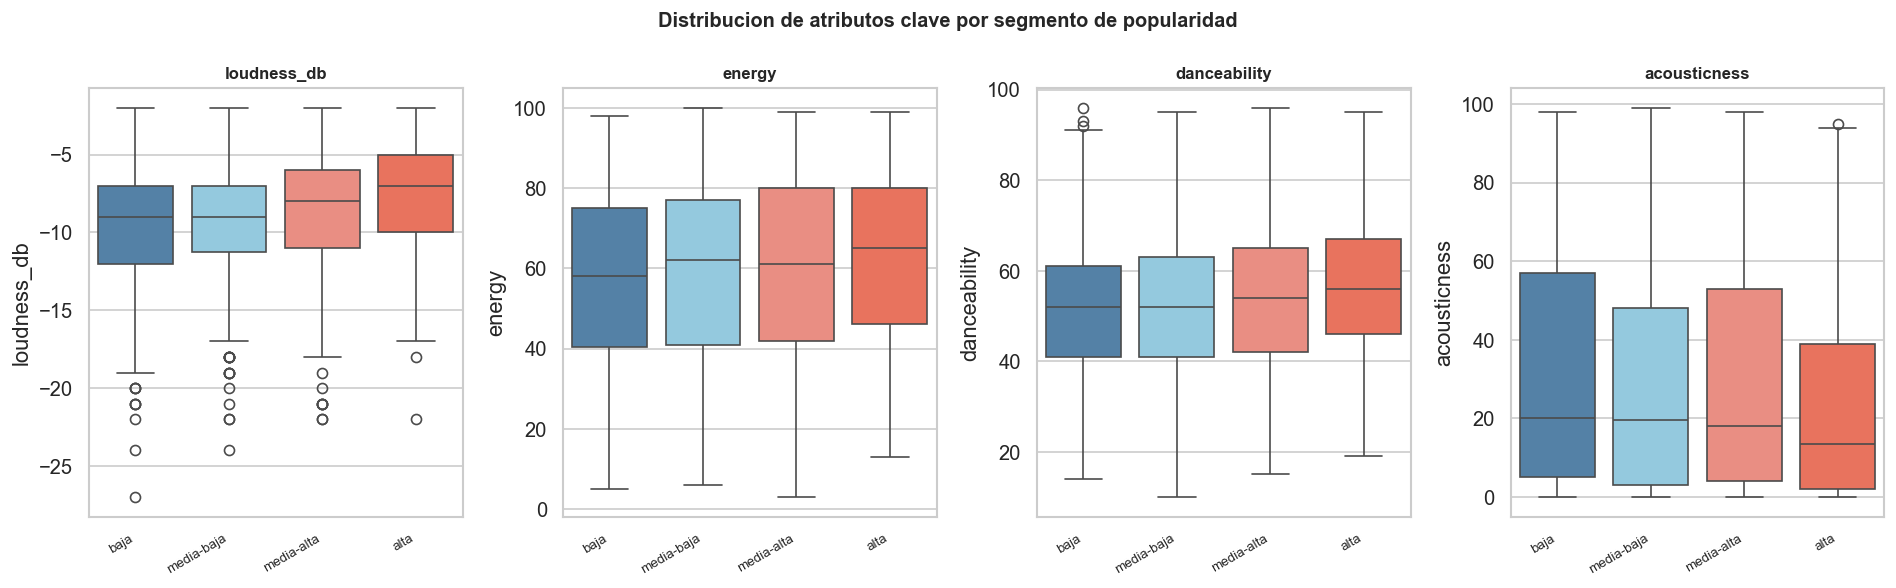

In [26]:
# 8.3 Boxplots - atributos clave por segmento
atributos_box = ['loudness_db', 'energy', 'danceability', 'acousticness']
paleta = ['steelblue', 'skyblue', 'salmon', 'tomato']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, atributos_box):
    sns.boxplot(data=df, x='popularity_segment', y=col,
                order=ORDEN_SEGMENTOS, palette=paleta, ax=ax)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ORDEN_SEGMENTOS, rotation=30, ha='right', fontsize=8)

plt.suptitle('Distribucion de atributos clave por segmento de popularidad',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Analisis por genero y por decada

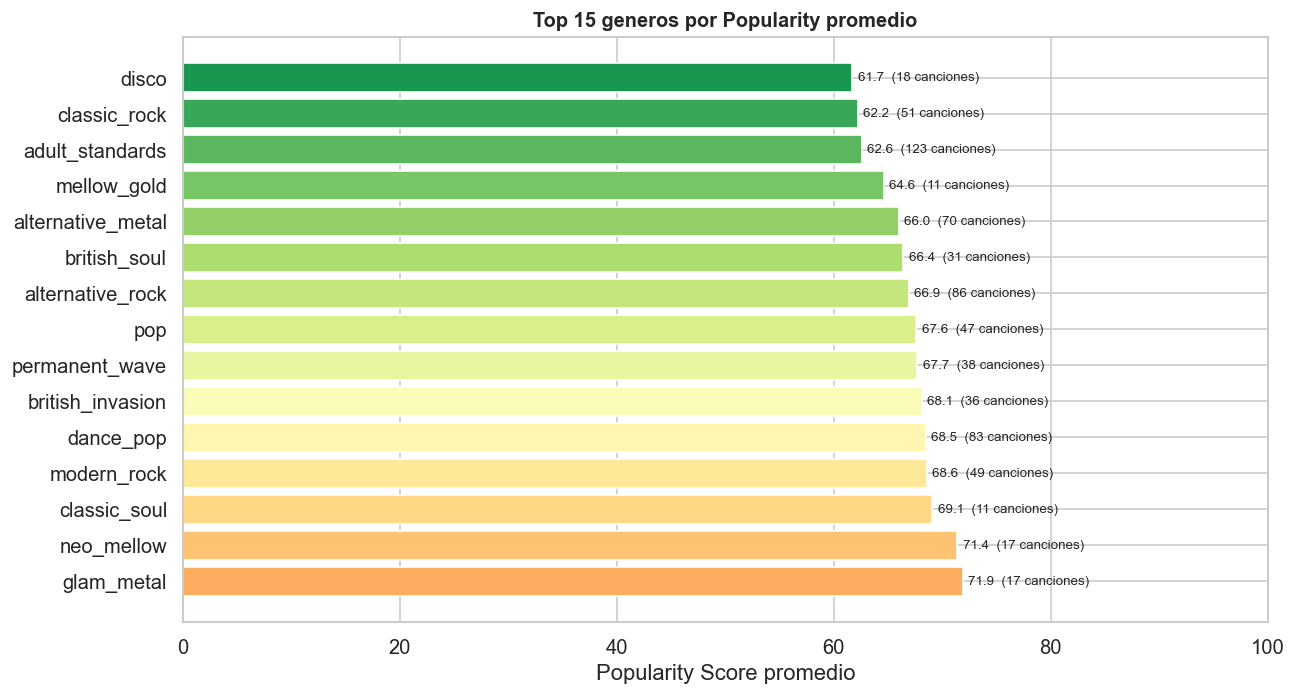

In [27]:
# 9.1 Top 15 generos por popularidad promedio (min. 10 canciones)
popularidad_genero = (
    df.groupby('genre')
    .agg(canciones=('popularity','count'), pop_media=('popularity','mean'))
    .query('canciones >= 10')
    .sort_values('pop_media', ascending=False)
    .head(15)
    .round(1)
)

fig, ax = plt.subplots(figsize=(11, 6))
colores_g = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(popularidad_genero)))
ax.barh(popularidad_genero.index, popularidad_genero['pop_media'],
        color=colores_g, edgecolor='white')
ax.set_title('Top 15 generos por Popularity promedio',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Popularity Score promedio')
ax.set_xlim(0, 100)

for i, (_, row) in enumerate(popularidad_genero.iterrows()):
    ax.text(row['pop_media'] + 0.5, i,
            f"{row['pop_media']:.1f}  ({int(row['canciones'])} canciones)",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

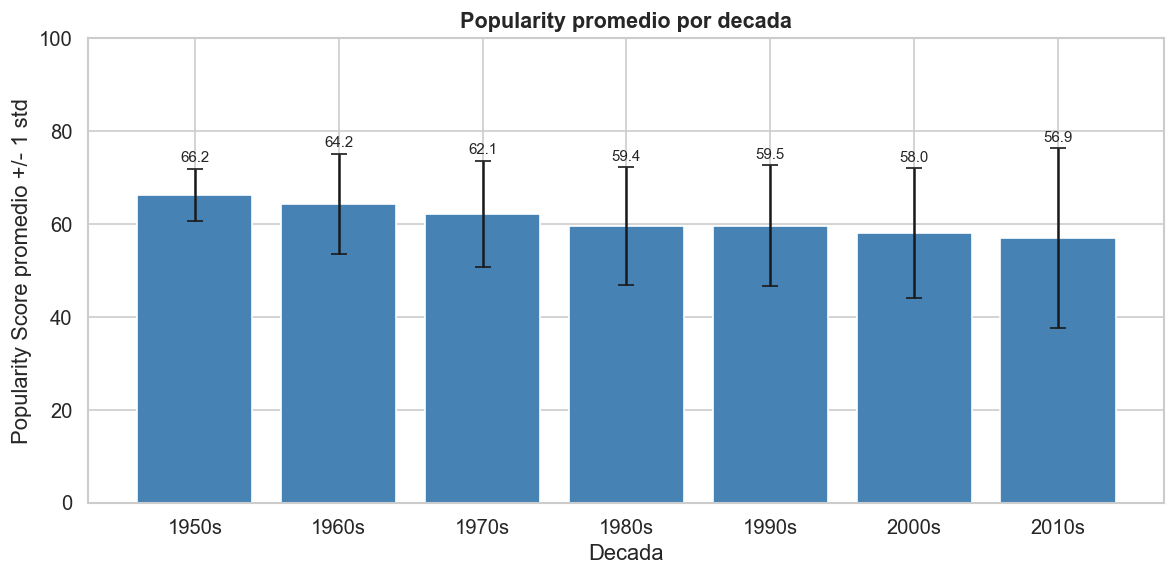

              canciones  pop_media  pop_std
decade_label                               
1950s                 9       66.2      5.6
1960s               158       64.2     10.8
1970s               353       62.1     11.4
1980s               344       59.4     12.7
1990s               331       59.5     13.0
2000s               400       58.0     13.9
2010s               399       56.9     19.3


In [28]:
# 9.2 Popularidad promedio por decada
popularidad_decada = (
    df.groupby('decade_label')
    .agg(canciones=('popularity','count'),
         pop_media=('popularity','mean'),
         pop_std  =('popularity','std'))
    .sort_index()
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(popularidad_decada.index, popularidad_decada['pop_media'],
       yerr=popularidad_decada['pop_std'],
       color='steelblue', edgecolor='white', capsize=5)
ax.set_title('Popularity promedio por decada',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Decada')
ax.set_ylabel('Popularity Score promedio +/- 1 std')
ax.set_ylim(0, 100)

for i, (dec, row) in enumerate(popularidad_decada.iterrows()):
    ax.text(i, row['pop_media'] + row['pop_std'] + 1.5,
            f"{row['pop_media']:.1f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(popularidad_decada.to_string())

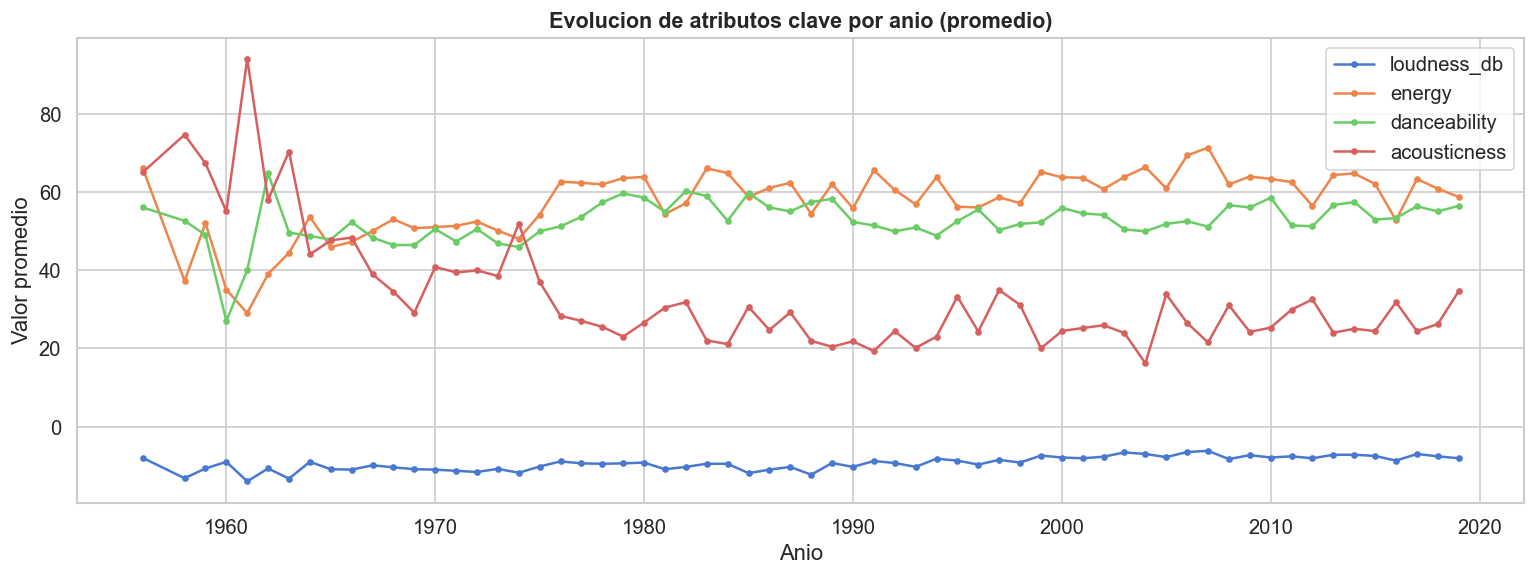

In [29]:
# 9.3 Evolucion temporal - atributos de la cadena
atributos_tiempo = ['loudness_db', 'energy', 'danceability', 'acousticness']
evolucion = df.groupby('year')[atributos_tiempo].mean().round(1)

fig, ax = plt.subplots(figsize=(13, 5))
for col in atributos_tiempo:
    ax.plot(evolucion.index, evolucion[col],
            marker='o', markersize=3, linewidth=1.5, label=col)

ax.set_title('Evolucion de atributos clave por anio (promedio)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Anio')
ax.set_ylabel('Valor promedio')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 10. Cruce con Grammy Awards

In [30]:
# 10.1 Popularidad: Grammy vs No Grammy
comparacion_grammy = (
    df.groupby('winner')['popularity']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
)
comparacion_grammy.index = ['Sin Grammy', 'Con Grammy']
print('Comparacion de Popularity:')
print(comparacion_grammy)
print()
diferencia = comparacion_grammy.loc['Con Grammy', 'mean'] - comparacion_grammy.loc['Sin Grammy', 'mean']
print(f'Diferencia: +{diferencia:.1f} puntos a favor de artistas con Grammy')

Comparacion de Popularity:
             mean  median    std  count
Sin Grammy  58.93    61.0  14.37   1882
Con Grammy  69.62    72.0   9.57    112

Diferencia: +10.7 puntos a favor de artistas con Grammy


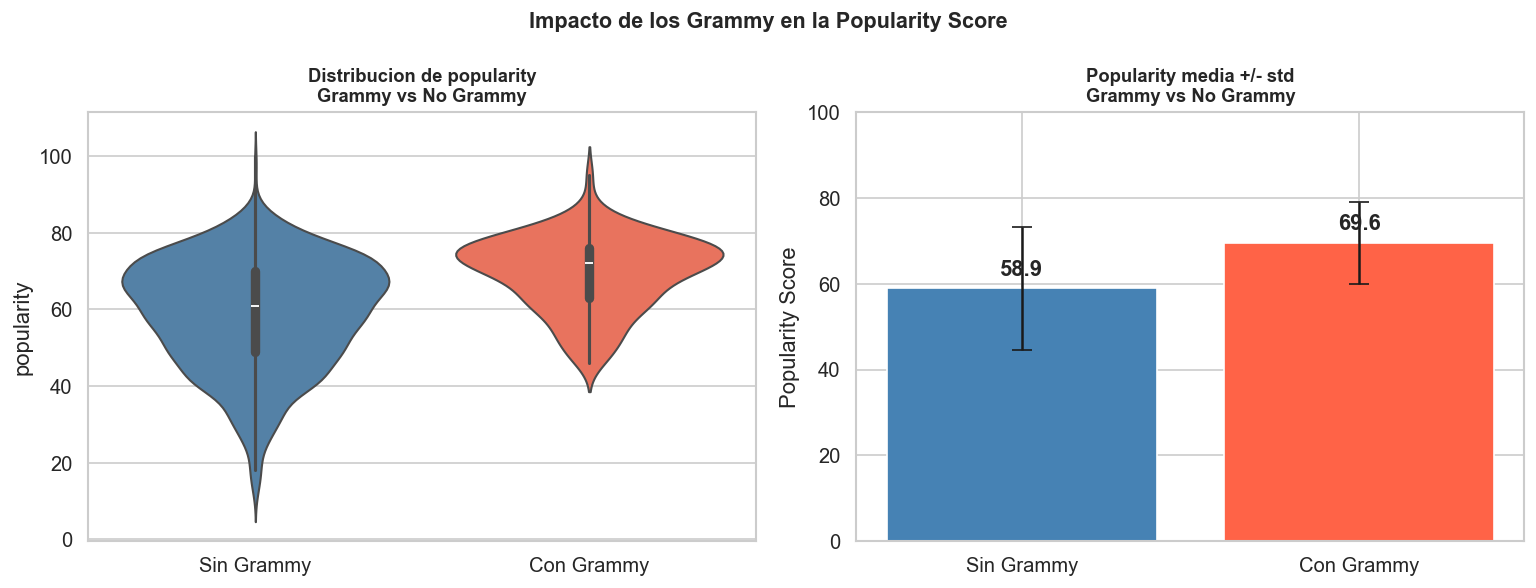

In [31]:
# 10.2 Visualizacion: violinplot + barras
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df, x='winner', y='popularity',
               palette={'False': 'steelblue', 'True': 'tomato'}, ax=axes[0])
axes[0].set_xticklabels(['Sin Grammy', 'Con Grammy'])
axes[0].set_title('Distribucion de popularity\nGrammy vs No Grammy',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('')

medias = df.groupby('winner')['popularity'].mean()
stds   = df.groupby('winner')['popularity'].std()
barras = axes[1].bar(['Sin Grammy', 'Con Grammy'], medias.values,
                     yerr=stds.values, color=['steelblue', 'tomato'],
                     capsize=6, edgecolor='white')
axes[1].set_ylim(0, 100)
axes[1].set_title('Popularity media +/- std\nGrammy vs No Grammy',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Popularity Score')

for barra, val in zip(barras, medias.values):
    axes[1].text(barra.get_x() + barra.get_width() / 2., val + 2,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Impacto de los Grammy en la Popularity Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

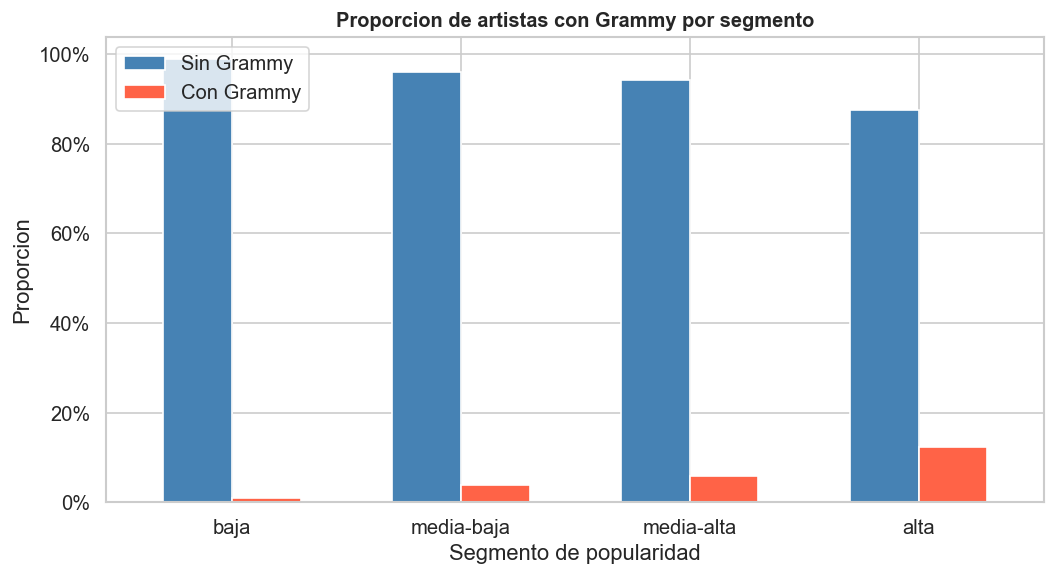

% Con Grammy por segmento:
popularity_segment
baja           1.0
media-baja     3.9
media-alta     5.8
alta          12.4


In [32]:
# 10.3 Proporcion de artistas con Grammy por segmento
tabla_cruzada = (
    pd.crosstab(df['popularity_segment'], df['winner'], normalize='index')
    .reindex(ORDEN_SEGMENTOS)
)
tabla_cruzada.columns = ['Sin Grammy', 'Con Grammy']

fig, ax = plt.subplots(figsize=(9, 5))
tabla_cruzada.plot(kind='bar', ax=ax,
                   color=['steelblue', 'tomato'], edgecolor='white', width=0.6)
ax.set_title('Proporcion de artistas con Grammy por segmento',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Segmento de popularidad')
ax.set_ylabel('Proporcion')
ax.set_xticklabels(ORDEN_SEGMENTOS, rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('% Con Grammy por segmento:')
print((tabla_cruzada['Con Grammy'] * 100).round(1).to_string())

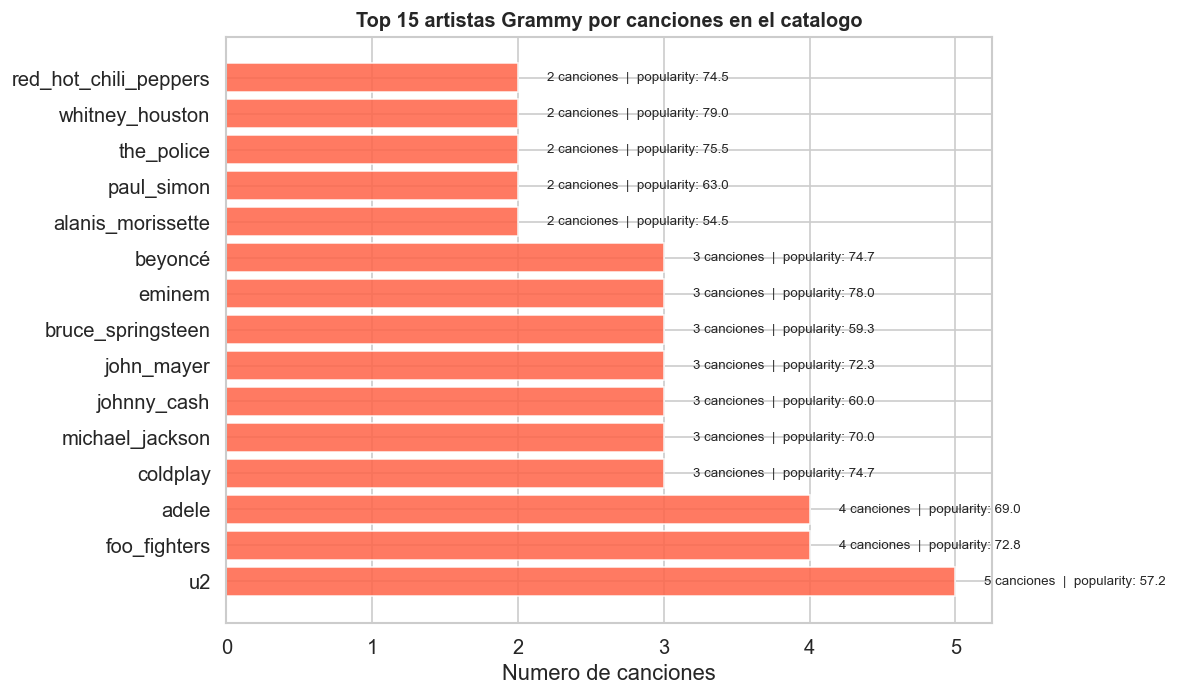

In [33]:
# 10.4 Top artistas Grammy por presencia en el catalogo
top_artistas_grammy = (
    df[df['winner'] == True]
    .groupby('artist')
    .agg(canciones=('title','count'), pop_media=('popularity','mean'))
    .sort_values('canciones', ascending=False)
    .head(15)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_artistas_grammy.index, top_artistas_grammy['canciones'],
        color='tomato', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 artistas Grammy por canciones en el catalogo',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Numero de canciones')

for i, (_, row) in enumerate(top_artistas_grammy.iterrows()):
    ax.text(row['canciones'] + 0.2, i,
            f"{int(row['canciones'])} canciones  |  popularity: {row['pop_media']:.1f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 11. Hallazgos clave y recomendaciones de negocio

In [36]:
# Recalculo de valores clave
popularidad_genero_res = (
    df.groupby('genre')
    .agg(canciones=('popularity','count'), pop_media=('popularity','mean'))
    .query('canciones >= 10')
    .sort_values('pop_media', ascending=False)
)
popularidad_decada_res = df.groupby('decade_label')['popularity'].mean().round(1)
comparacion_res        = df.groupby('winner')['popularity'].mean().round(1)

top_genero    = popularidad_genero_res.index[0]
top_genero_sc = popularidad_genero_res.iloc[0]['pop_media']
decada_top    = popularidad_decada_res.idxmax()
diferencia_gm = comparacion_res.get(True, 0) - comparacion_res.get(False, 0)
pct_grammy    = df['winner'].mean() * 100
q_baja_media  = df[df['popularity_segment'] == 'baja']['popularity'].mean()
q_alta_media  = df[df['popularity_segment'] == 'alta']['popularity'].mean()
r_loud        = corr_con_popularity['loudness_db']
r_dance       = corr_con_popularity['danceability']
r_le          = matriz_corr.loc['loudness_db', 'energy']
r_ea          = matriz_corr.loc['energy', 'acousticness']

sep = '=' * 62
print(sep)
print('  RESUMEN - Spotify 2000 - Analisis de Popularity Score')
print(sep)
print(f'DATASET')
print(f"  {len(df):,} canciones  |  {df['year'].min()}-{df['year'].max()}")
print(f"  Popularity Score promedio: {df['popularity'].mean():.1f} / 100")
print()
print('CADENA DE ANALISIS PRINCIPAL')
print('  Paso 1 - Impacto directo en popularity:')
print(f'    loudness_db  r = {r_loud:.2f}  -> canciones mas fuertes = mas populares')
print(f'    danceability r = {r_dance:.2f}  -> canciones mas bailables = mas populares')
print()
print('  Paso 2 - Que hay detras del volumen?')
print(f'    loudness_db <-> energy       r = {r_le:.2f}  -> fuertes = energeticas')
print(f'    energy <-> acousticness      r = {r_ea:.2f}  -> acusticas = menos energeticas')
print()
print('  Conclusion: dos perfiles opuestos en el catalogo:')
print('    Perfil A (energetico + fuerte + bailable) -> mayor popularidad')
print('    Perfil B (acustico + tranquilo)           -> menor popularidad')
print()
print('BRECHA ENTRE SEGMENTOS')
print(f'  Alto rendimiento (alta): {q_alta_media:.1f} pts')
print(f'  Bajo rendimiento (baja): {q_baja_media:.1f} pts')
print(f'  Brecha: {q_alta_media - q_baja_media:.1f} puntos')
print()
print('GENEROS Y DECADAS')
print(f'  Genero con mayor popularity: {top_genero} ({top_genero_sc:.1f} pts)')
print(f'  Decada con mayor popularity: {decada_top}')
print()
print('IMPACTO DE LOS GRAMMY')
print(f'  Artistas con Grammy: {pct_grammy:.1f}% del catalogo')
print(f'  Diferencia Grammy vs No Grammy: +{diferencia_gm:.1f} puntos')
print()
print('RECOMENDACIONES')
print(f'  1. Priorizar loudness y danceability en playlists editoriales.')
print(f'  2. El Perfil A es el standard de contenido de alto rendimiento.')
print(f'  3. Artistas con Grammy tienen +{diferencia_gm:.1f} pts.')
print(sep)
print('  Proximos pasos: Modelo de regresion + Clustering K-Means')
print(sep)

  RESUMEN - Spotify 2000 - Analisis de Popularity Score
DATASET
  1,994 canciones  |  1956-2019
  Popularity Score promedio: 59.5 / 100

CADENA DE ANALISIS PRINCIPAL
  Paso 1 - Impacto directo en popularity:
    loudness_db  r = 0.17  -> canciones mas fuertes = mas populares
    danceability r = 0.14  -> canciones mas bailables = mas populares

  Paso 2 - Que hay detras del volumen?
    loudness_db <-> energy       r = 0.74  -> fuertes = energeticas
    energy <-> acousticness      r = -0.67  -> acusticas = menos energeticas

  Conclusion: dos perfiles opuestos en el catalogo:
    Perfil A (energetico + fuerte + bailable) -> mayor popularidad
    Perfil B (acustico + tranquilo)           -> menor popularidad

BRECHA ENTRE SEGMENTOS
  Alto rendimiento (alta): 76.6 pts
  Bajo rendimiento (baja): 39.8 pts
  Brecha: 36.8 puntos

GENEROS Y DECADAS
  Genero con mayor popularity: glam_metal (71.9 pts)
  Decada con mayor popularity: 1950s

IMPACTO DE LOS GRAMMY
  Artistas con Grammy: 5.6% del 

In [35]:
# Exportar dataset enriquecido
df.to_csv('spotify_eda_clean.csv', index=False)
print('Dataset exportado como: spotify_eda_clean.csv')
print(f'Columnas: {df.columns.tolist()}')

Dataset exportado como: spotify_eda_clean.csv
Columnas: ['title', 'artist', 'genre', 'year', 'bpm', 'energy', 'danceability', 'loudness_db', 'liveness', 'valence', 'duration', 'acousticness', 'speechiness', 'popularity', 'decade', 'popularity_segment', 'winner', 'decade_label']
